# Active Discovery of Latent Dynamic Mediators

To start we assume that in our training set we have recordings of $N$ independent patients. Each patient $n$ is associated with two time series signals, $x_n(t)$ and $y_n(t)$, and a treatment group label $c_n \in \mathcal{C}$ provided by an expert. The treatment group $c_n$ identifies which causal pathway is responsible for generating $y_n(t)$. The pathway $c_n$ is associated with a particular causal model $M_{c_n}$ that generated $y_n(t)$  conditional on a latent mediation process $z_n(t)$.

There are two SSMs indexed by $j\in \{0,1\}$, where $j$ represents the group:
$$z_t := \alpha_j x_t + \lambda_j z_{t-1} + w_t,
    \qquad w \sim \mathcal{N}(0,\sigma_w)$$
$$y_t := \beta_j z_{t} + \gamma_j x_t + e_t,
    \qquad e_t \sim \mathcal{N}(0,\sigma_e)
$$

In [1]:
from utils.data_generation import generate_synthetic_samples, PatientSimulator
from utils.plots import plot_scatter_by_group, plot_trajectories, plot_mean_std, plot_accuracy_active_learning
from utils.em_algorithm import em_ssm
from utils.infer_patient import infer_patient
from utils.active_learning import run_patient_with_active_learning
from utils.baseline import logistic_regression_prediction
import numpy as np

## Phase 1: training

### Data Visualization

In [2]:
# generate synthetic training samples
j_train, X_train, Z_train, Y_train = generate_synthetic_samples(n_patients=100, T=50)

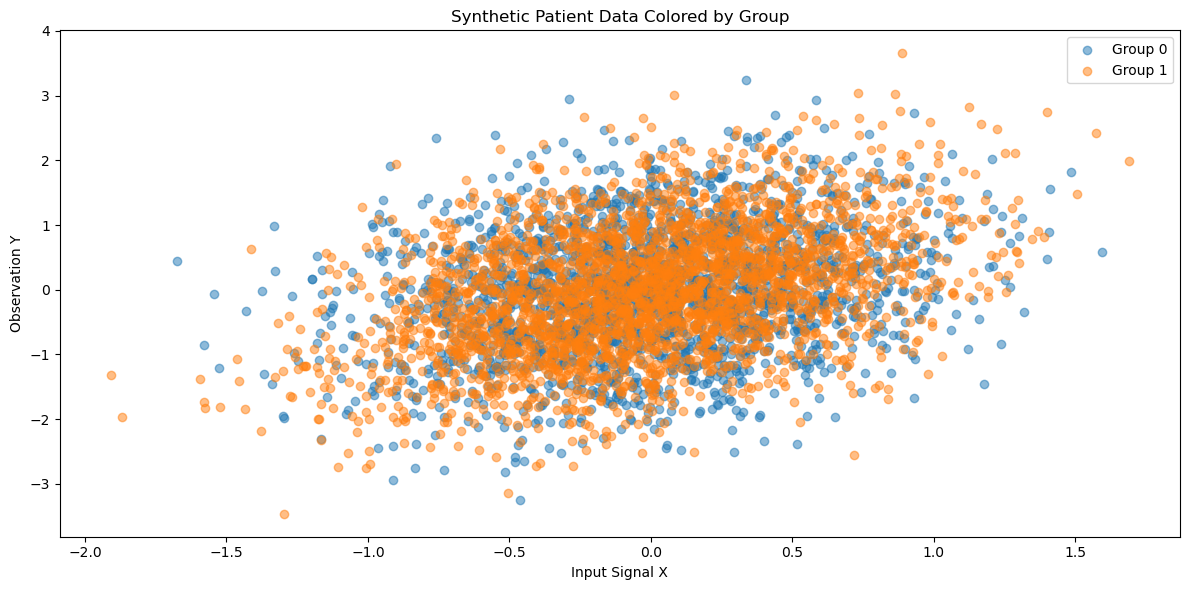

In [3]:
plot_scatter_by_group(X_train, Y_train, groups=j_train)

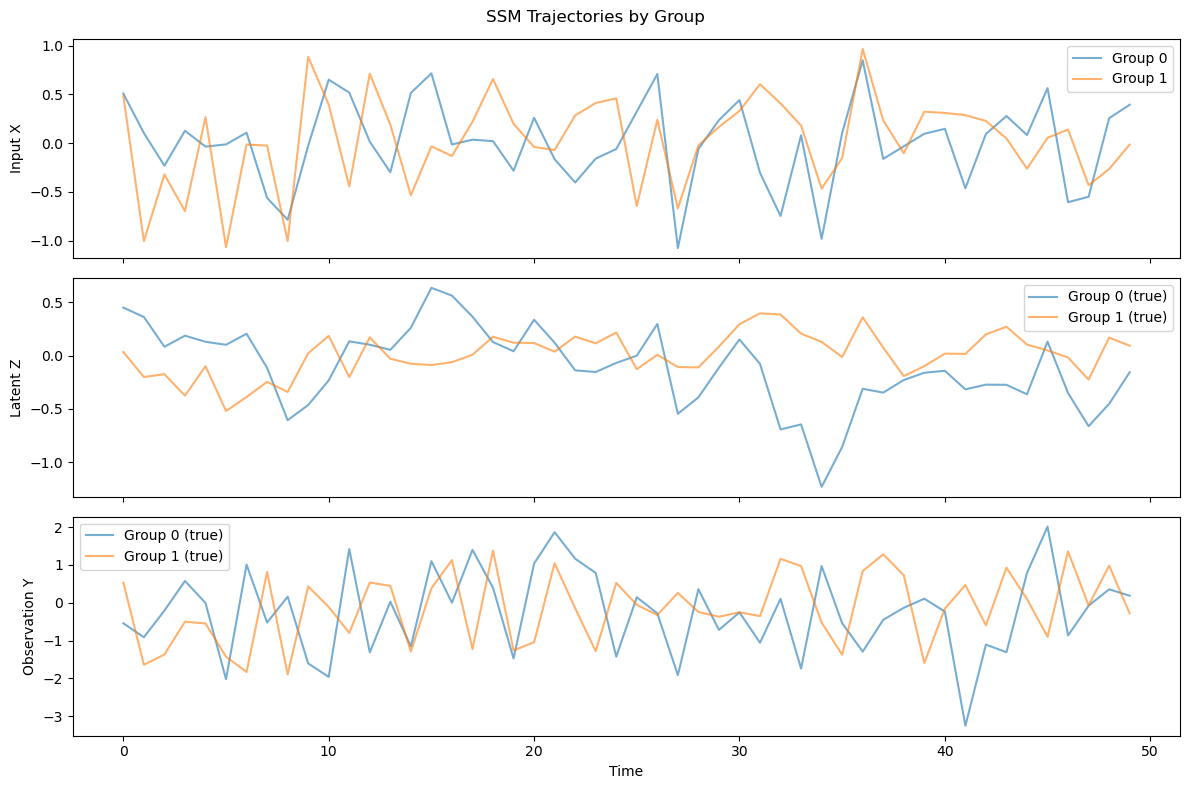

In [4]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train)

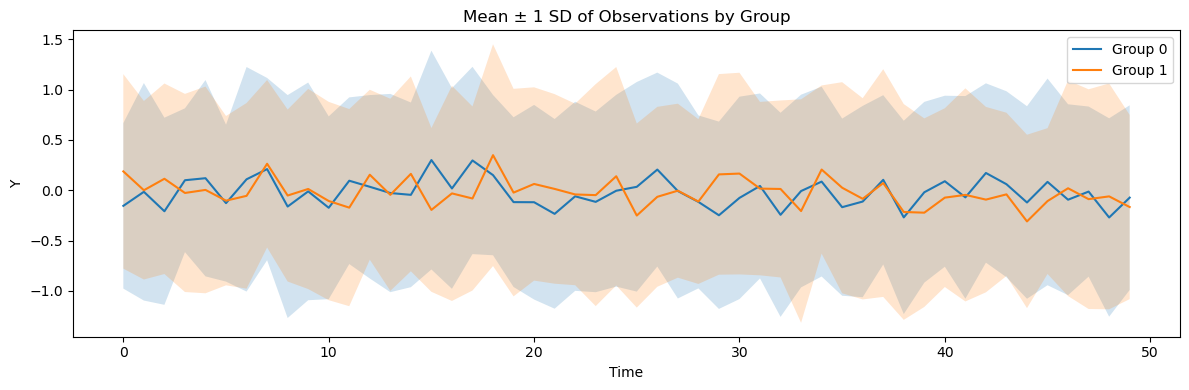

In [5]:
plot_mean_std(Y_train, groups=j_train)

### Estimation using EM algorithm

In [6]:
# separate the data into the two groups
# run em algorithm on each group separately
estimated_params = {}
for group in [0, 1]:
        idx = j_train == group
        X_group = X_train[idx]
        Y_group = Y_train[idx]
 
        params, log_liks = em_ssm(
            X_group, Y_group,
            alpha_init=0.5, lam_init=0.5, beta_init=0.5, gamma_init=0.5,
            sigma_w_init=0.2, sigma_e_init=0.2,
        )

        estimated_params[group] = params
 
        print(f"\nGroup {group} estimated params:")
        for k, v in params.items():
            print(f"  {k}: {v:.4f}")
            #print(f"Log-likelihood: {log_liks}.")


Group 0 estimated params:
  alpha: 0.6542
  lam: 0.7203
  beta: 0.4621
  gamma: 0.1608
  sigma_w: 0.3586
  sigma_e: 0.8808

Group 1 estimated params:
  alpha: 0.5812
  lam: 0.1500
  beta: 1.0826
  gamma: 0.1447
  sigma_w: 0.3628
  sigma_e: 0.7889


### Visualize the Predicted Trajectories of $z_t$ and $y_t$

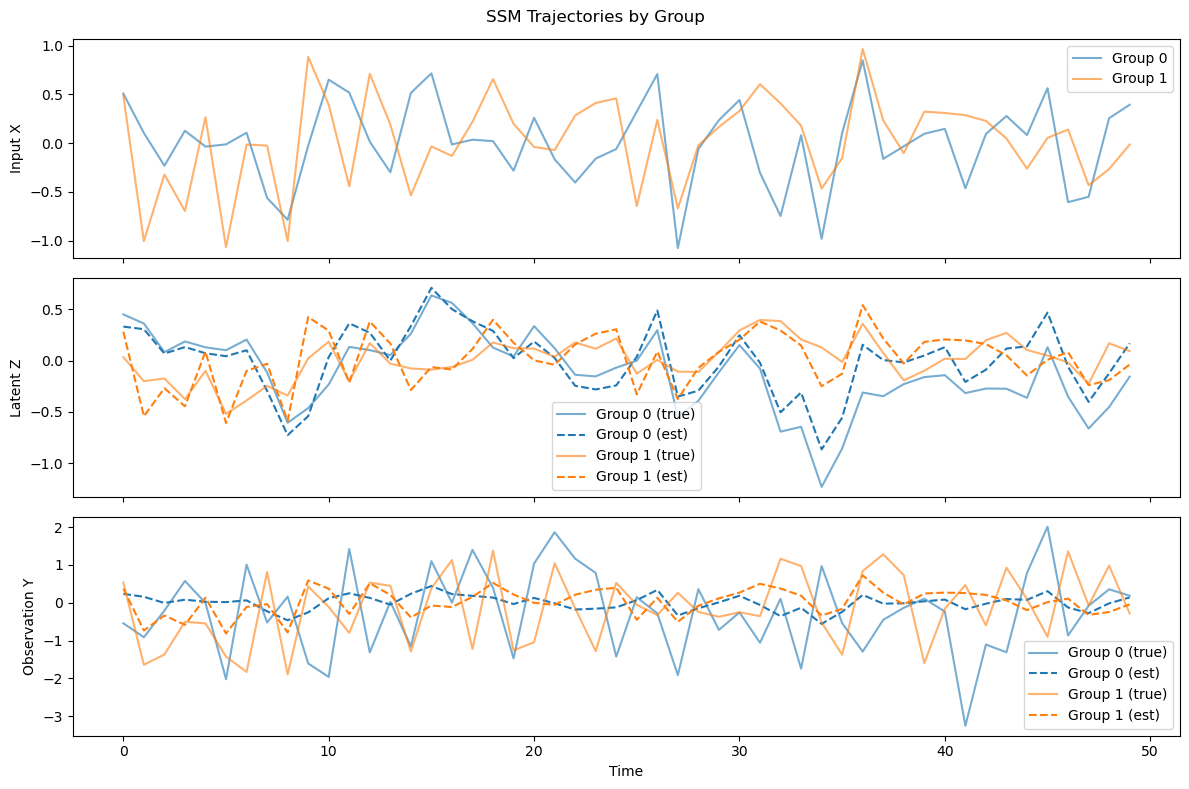

In [7]:
plot_trajectories(X_train, Z_train, Y_train, groups=j_train, estimated_params=estimated_params)

## Phase 2: classification via filtering

In [8]:
# generate synthetic testing samples
j_test, X_test, Z_test, Y_test = generate_synthetic_samples(n_patients=100, T=50)


Patient 0 true group: 0


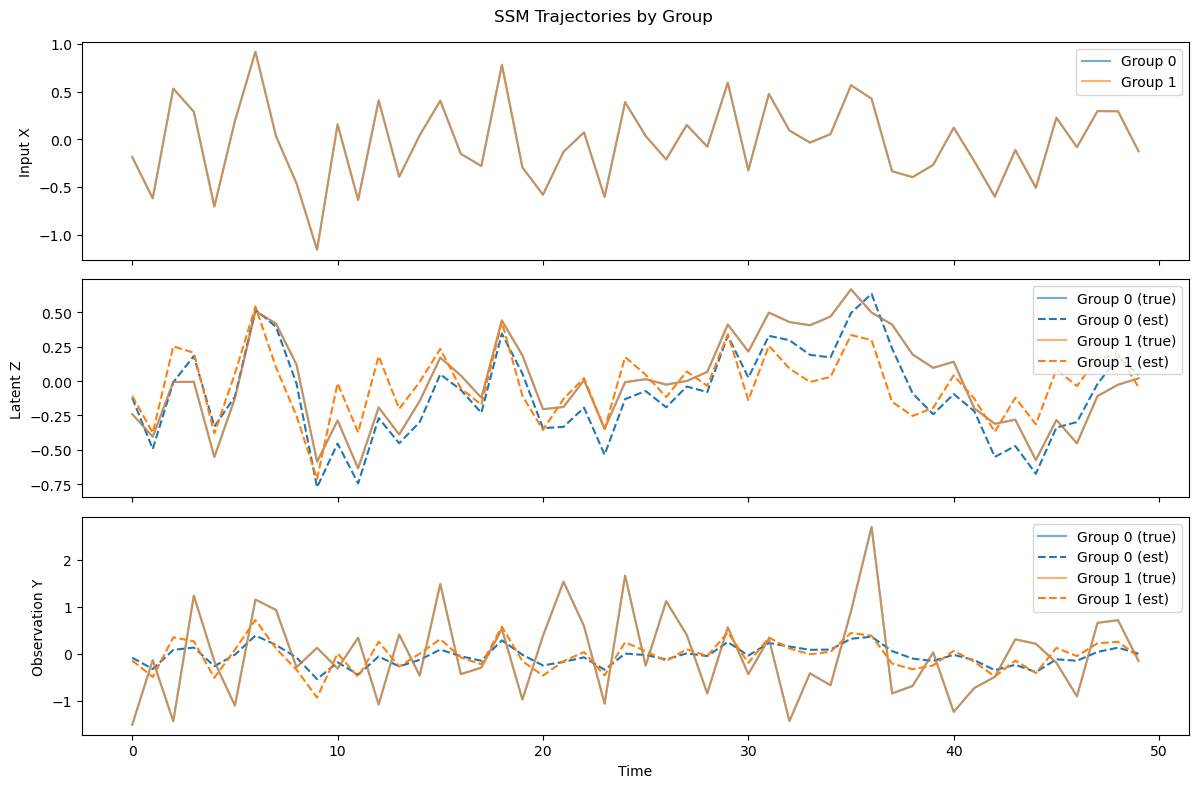

Our approach:
Accuracy: 0.7900  (79/100 correct)

Baseline approach (logistic regression):
Accuracy (using full time series): 0.5200  (52/100 correct)
Accuracy (using moments): 0.4800  (48/100 correct)


In [9]:
predictions = []
for n in range(len(j_test)):
    if n == 0:
        print(f"\nPatient {n} true group: {j_test[n]}")
        # display patient trajectory under both models
        X_display = np.array([X_test[n], X_test[n]])  # duplicate for both models
        Z_display = np.array([Z_test[n], Z_test[n]])  # duplicate for both models
        Y_display = np.array([Y_test[n], Y_test[n]])  # duplicate for both models
        j_display = np.array([0, 1])  # both groups
        plot_trajectories(X_display, Z_display, Y_display, groups=j_display, estimated_params=estimated_params)
    prob_1, c_n, _, _ = infer_patient(X_test[n], Y_test[n], estimated_params[0], estimated_params[1])
    predictions.append(c_n)

predictions = np.array(predictions)
accuracy = np.mean(predictions == j_test)
print("Our approach:")
print(f"Accuracy: {accuracy:.4f}  ({int(accuracy * len(j_test))}/{len(j_test)} correct)")

print("\nBaseline approach (logistic regression):")
baseline_predictions = logistic_regression_prediction(X_train, Y_train, j_train, X_test, Y_test, variant='full time series')
baseline_accuracy = np.mean(baseline_predictions == j_test)
print(f"Accuracy (using full time series): {baseline_accuracy:.4f}  ({int(baseline_accuracy * len(j_test))}/{len(j_test)} correct)")

baseline_predictions_moments = logistic_regression_prediction(X_train, Y_train, j_train, X_test, Y_test, variant='distribution moments')
baseline_accuracy_moments = np.mean(baseline_predictions_moments == j_test)
print(f"Accuracy (using moments): {baseline_accuracy_moments:.4f}  ({int(baseline_accuracy_moments * len(j_test))}/{len(j_test)} correct)")

### Active learning

/remote/rds/users/s2020748/mediators/utils/active_learning.py:19: RuntimeWarning: divide by zero encountered in log
  log_post_0 = log_lik_0 + np.log(prior_0)
/remote/rds/users/s2020748/mediators/utils/active_learning.py:20: RuntimeWarning: divide by zero encountered in log
  log_post_1 = log_lik_1 + np.log(prior_1)


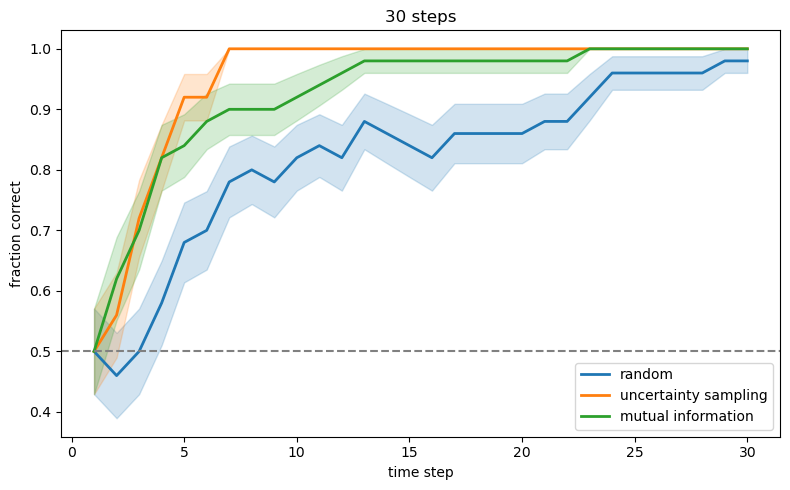

In [10]:
n_patients = 50
T = 30
policies = ["random", "uncertainty sampling", "mutual information"]
# to account for time step 0
correct = {pol: np.zeros((n_patients, T), dtype=bool) for pol in policies}
candidates = np.linspace(-4, 4, 33)

for i in range(n_patients):
    true_group = i % 2
    #patient = PatientSimulator(true_group)

    for policy in policies:
        patient = PatientSimulator(true_group)
        _, correct_t = run_patient_with_active_learning(patient, estimated_params, candidates, policy=policy, T=T)
        correct[policy][i] = correct_t

accuracy = {pol: correct[pol].mean(axis=0) for pol in policies} 
sem = {pol: correct[pol].std(axis=0)/np.sqrt(n_patients) for pol in policies} # standard error of the mean

plot_accuracy_active_learning(accuracy, sem)